In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\saura\Data Science\MATERIALS\Datasets\netflix_titles.csv")

In [4]:
print("First 5 rows of the Dataset:")
df.head()

First 5 rows of the Dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("Shape of the Dataset:",df.shape)

Shape of the Dataset: (8807, 12)


In [6]:
print("Null values information in the dataset:",df.isnull().sum())

Null values information in the dataset: show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [7]:
#Filling Missing values with the most suitable value OR Drooping null values
df['country']=df['country'].fillna(df['country'].mode()[0])
df.dropna(subset=['date_added','rating'],inplace=True)

In [8]:
df['date_added']=pd.to_datetime(df['date_added'].str.strip())
df['Year_added']=df['date_added'].dt.year

In [9]:
sns.set_theme(style='whitegrid')

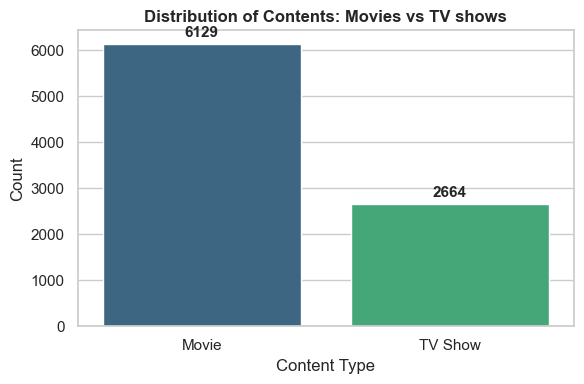

In [10]:
# Answering Question 1:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='type', hue='type', palette='viridis', legend=False)
plt.title('Distribution of Contents: Movies vs TV shows', fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Count')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fontweight='bold', fontsize=11, padding=3)

plt.tight_layout()
plt.show()

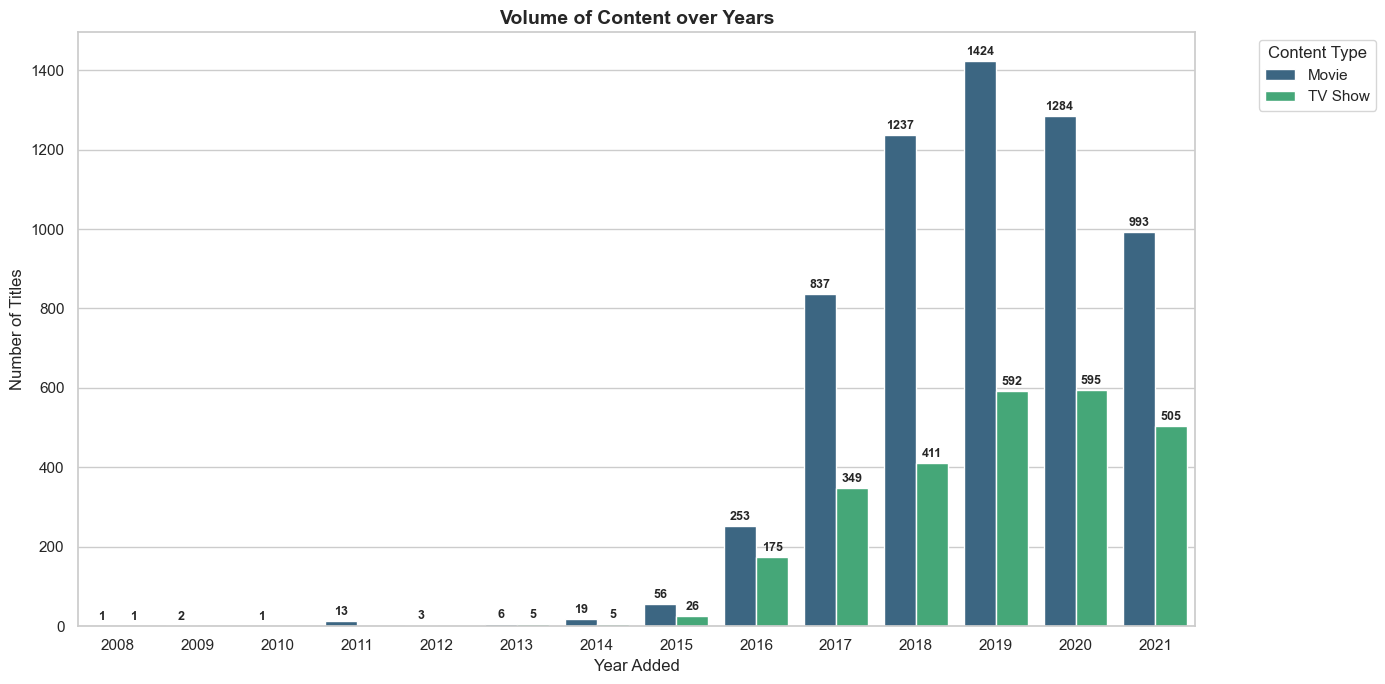

In [11]:
#Answering Question 2
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, 
                   x='Year_added', 
                   hue='type', 
                   palette='viridis')

plt.title('Volume of Content over Years', fontweight='bold', fontsize=14)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight='bold', padding=2)

plt.legend(title='Content Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

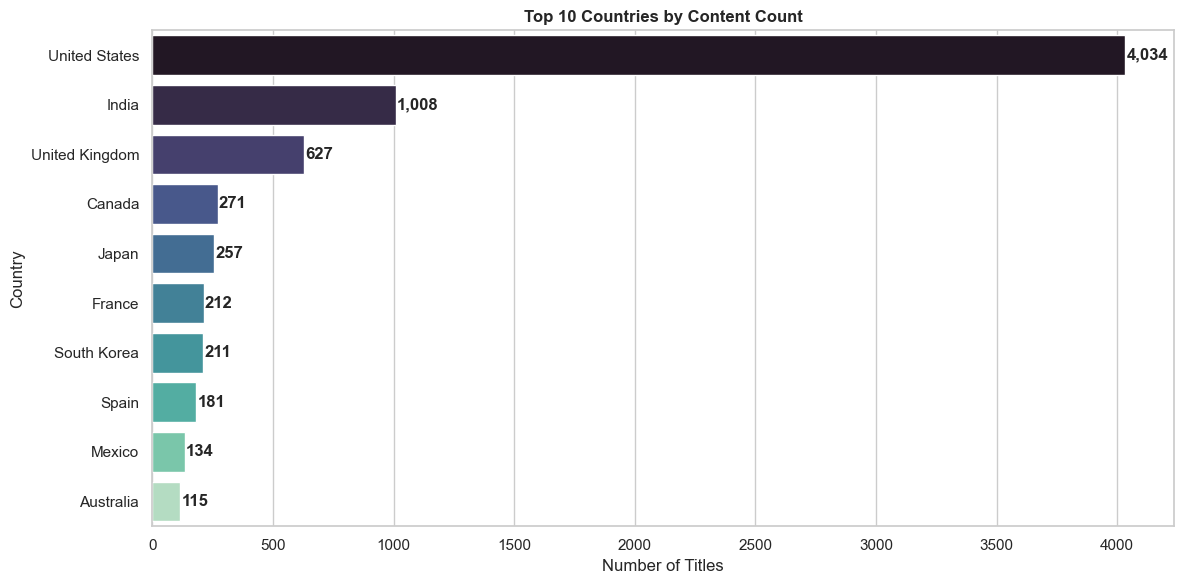

In [12]:
#Answering Question 3
df['cntry']=df['country'].apply(lambda x:x.split(',')[0])

top_10_countries = df['cntry'].value_counts().head(10)

# Convert to DataFrame for proper seaborn usage
top_10_df = pd.DataFrame({
    'country': top_10_countries.index,
    'count': top_10_countries.values
})

plt.figure(figsize=(12, 6))

# Fix 1: Add hue to use palette
# Fix 2: Use err_kws instead of errwidth
ax = sns.barplot(data=top_10_df,
                 y='country',
                 x='count',
                 hue='country',  # Added to use palette
                 palette='mako',
                 dodge=False,    # Prevents splitting bars
                 legend=False,   # Hides redundant legend
                 err_kws={'linewidth': 0})  # Replaces errwidth

plt.title('Top 10 Countries by Content Count', fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

# Add labels
for bar in ax.patches:
    width = bar.get_width()
    ax.text(width +5 , bar.get_y() + bar.get_height()/2.,
            f'{int(width):,}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

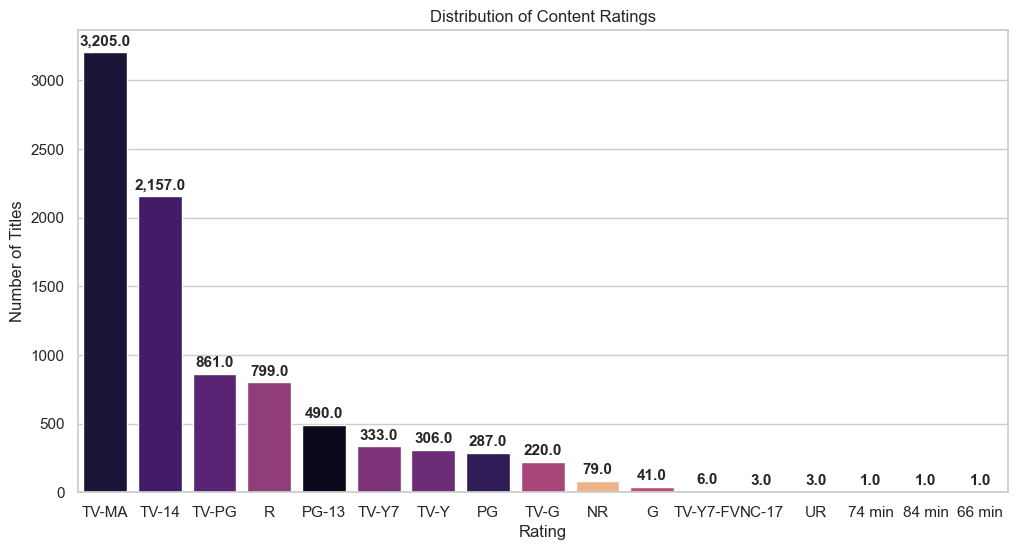

In [15]:
#Answering Question 4
plt.figure(figsize=(12, 6))
order = df['rating'].value_counts().index
ax = sns.countplot(x='rating', data=df,hue='rating', order=order, palette='magma')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

# Add labels with comma formatting for thousands
for container in ax.containers:
    ax.bar_label(container, fontweight='bold', fontsize=11, padding=3, fmt='{:,}')

plt.show()

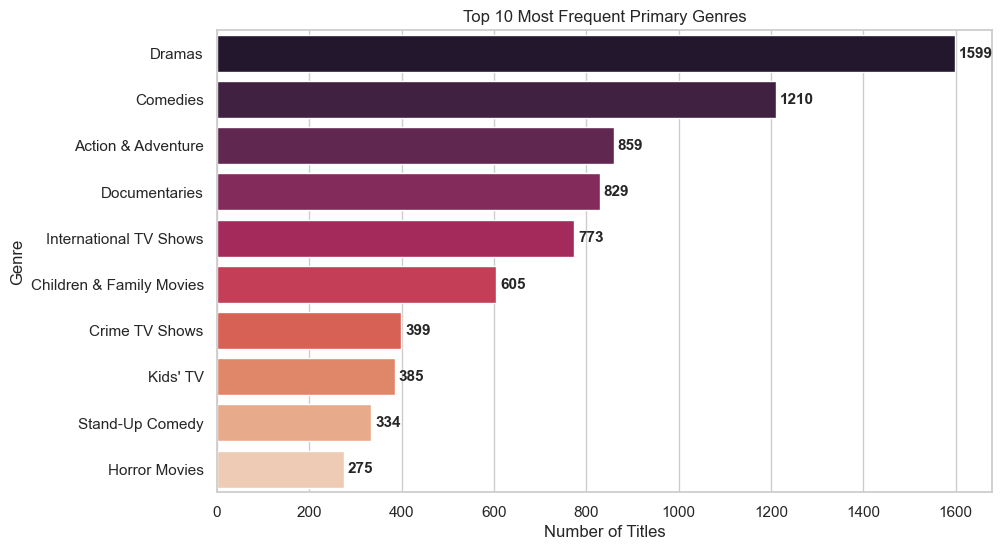

In [17]:
# Answering ques 5
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])
top_10_genres = df['primary_genre'].value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(y=top_10_genres.index, x=top_10_genres.values,hue=top_10_genres.index, palette='rocket',legend=False)
plt.title('Top 10 Most Frequent Primary Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

# Add labels at the end of each horizontal bar
for container in ax.containers:
    ax.bar_label(container, fontweight='bold', fontsize=11, padding=3)

plt.show()